
[DEBUG] Processing data1
data1 | 101 vs 102: UNMATCHED (18 good matches)
data1 | 101 vs 103: UNMATCHED (8 good matches)
data1 | 101 vs 104: UNMATCHED (2 good matches)
data1 | 101 vs 105: UNMATCHED (10 good matches)
data1 | 101 vs 106: UNMATCHED (9 good matches)
data1 | 101 vs 107: UNMATCHED (16 good matches)
data1 | 101 vs 108: UNMATCHED (4 good matches)
data1 | 101 vs 109: UNMATCHED (8 good matches)
data1 | 101 vs 110: UNMATCHED (5 good matches)
data1 | 102 vs 103: UNMATCHED (2 good matches)
data1 | 102 vs 104: UNMATCHED (2 good matches)
data1 | 102 vs 105: UNMATCHED (4 good matches)
data1 | 102 vs 106: UNMATCHED (1 good matches)
data1 | 102 vs 107: UNMATCHED (3 good matches)
data1 | 102 vs 108: UNMATCHED (4 good matches)
data1 | 102 vs 109: UNMATCHED (3 good matches)
data1 | 102 vs 110: UNMATCHED (1 good matches)
data1 | 103 vs 104: UNMATCHED (1 good matches)
data1 | 103 vs 105: UNMATCHED (4 good matches)
data1 | 103 vs 106: UNMATCHED (2 good matches)
data1 | 103 vs 107: UNMATCHED (

<Figure size 600x500 with 0 Axes>

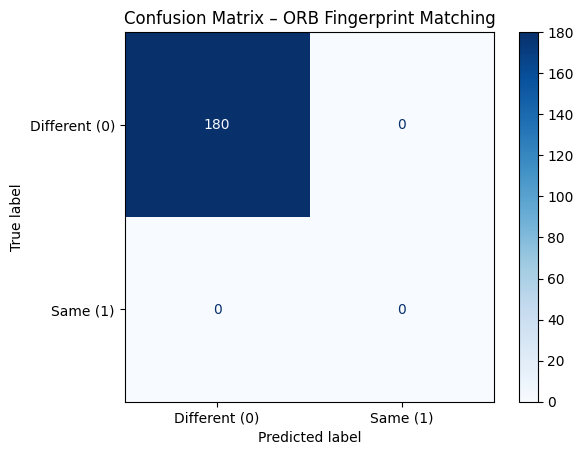

In [9]:
import cv2
import numpy as np
import os
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

def preprocess_fingerprint(image_path):
    img = cv2.imread(image_path, 0)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    morph = cv2.morphologyEx(enhanced, cv2.MORPH_CLOSE, kernel)

    _, img_bin = cv2.threshold(morph, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return img_bin

def match_fingerprints(img1_path, img2_path):
    img1 = preprocess_fingerprint(img1_path)
    img2 = preprocess_fingerprint(img2_path)

    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return 0, None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)
    good_matches = [m for m, n in matches if m.distance < 0.7 * n.distance]

    match_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return len(good_matches), match_img

def process_dataset(dataset_path, results_folder):
    threshold = 20
    y_true = []
    y_pred = []

    try:
        os.makedirs(results_folder, exist_ok=True)
    except PermissionError:
        print("Permission denied. Saving to local './match_results'")
        results_folder = './match_results'
        os.makedirs(results_folder, exist_ok=True)

    for folder in sorted(os.listdir(dataset_path)):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue

        print(f"\n[DEBUG] Processing {folder}")
        subfolders = [sub for sub in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, sub))]

        images = []
        for sub in sorted(subfolders):
            sub_path = os.path.join(folder_path, sub)
            tif_files = [f for f in os.listdir(sub_path) if f.lower().endswith('.tif')]
            if not tif_files:
                print(f"Skipping {sub_path}: no .tif files found")
                continue
            full_path = os.path.join(sub_path, tif_files[0])
            images.append((sub, full_path))

        if len(images) < 2:
            print(f"Skipping {folder}: not enough valid subfolders with images")
            continue

        for (label1, path1), (label2, path2) in itertools.combinations(images, 2):
            match_count, match_img = match_fingerprints(path1, path2)

            actual_match = 1 if label1 == label2 else 0
            predicted_match = 1 if match_count > threshold else 0

            y_true.append(actual_match)
            y_pred.append(predicted_match)

            result_label = "matched" if predicted_match == 1 else "unmatched"
            match_name = f"{folder}_{label1}_vs_{label2}_{result_label}.png"

            print(f"{folder} | {label1} vs {label2}: {result_label.upper()} ({match_count} good matches)")
            if match_img is not None:
                save_path = os.path.join(results_folder, match_name)
                cv2.imwrite(save_path, match_img)

    if not y_true or not y_pred:
        print("No valid comparisons. Confusion matrix skipped.")
        return

    print("\nLabel Distribution:", Counter(y_true))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Different (0)", "Same (1)"])
    plt.figure(figsize=(6, 5))
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix – ORB Fingerprint Matching")
    plt.show()

# === CONFIGURATION ===
dataset_path = r"C:\Users\jwens\Desktop\CSUGlobal\GitHub\Projects\Graduate Projects - MS AI and Machine Learning\CSC515 Computer Vision\dataset_folder"
results_folder = r"C:\Users\jwens\Desktop\CSUGlobal\GitHub\Projects\Graduate Projects - MS AI and Machine Learning\CSC515 Computer Vision\match_results"

process_dataset(dataset_path, results_folder)
